# 1. Geometry Generation & Navigation Mesh

This notebook demonstrates CrowdRL's procedural geometry generator (Tiers 0–2)
and the navigation mesh construction that enables A* pathfinding.

**Key concepts:**
- All geometries are Shapely Polygons with holes (JuPedSim convention)
- Walkable area = polygon exterior; obstacles = polygon holes
- The navmesh is built once per geometry and reused every simulation step

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

from crowdrl_core.geometry import (
    build_navmesh,
    extract_wall_segments,
    sample_point_in_polygon,
    triangulate_polygon,
)
from crowdrl_core.navmesh import (
    find_path,
    is_reachable,
    next_waypoint_direction,
    path_deviation,
    shortest_path,
)
from crowdrl_env.geometry_generator import (
    GeometryConfig,
    GeometryTier,
    generate_geometry,
)
from crowdrl_env.visualiser import plot_geometry, plot_navmesh, plot_spawn_goal_regions, visualise_generated_geometry

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Tier 0 — Open Fields

Convex polygons with no obstacles. These are the simplest training environments —
agents just need to navigate to their goals without colliding with each other.

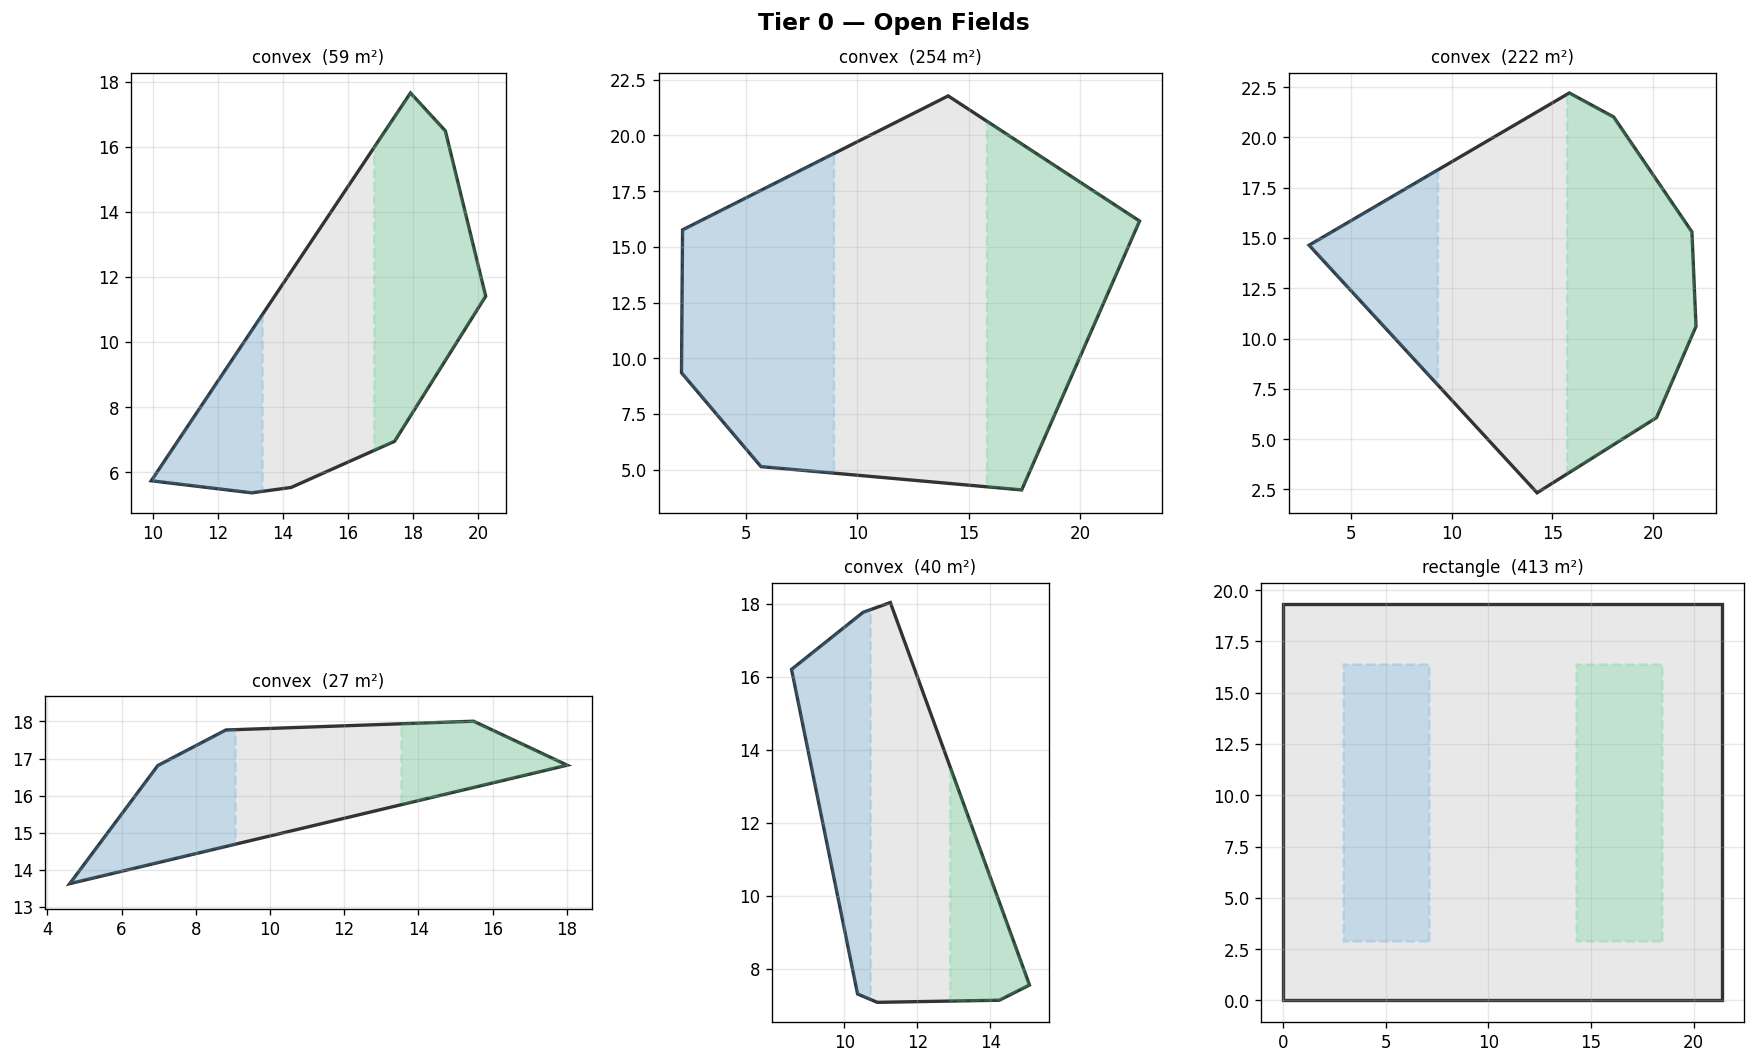

In [2]:
rng = np.random.default_rng(42)
config = GeometryConfig(tier=GeometryTier.TIER_0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax in axes.flat:
    geom = generate_geometry(rng, config)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    ax.set_title(f"{geom.metadata.get('shape', '?')}  ({geom.polygon.area:.0f} m²)", fontsize=10)

fig.suptitle("Tier 0 — Open Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Tier 1 — Corridors & Bottlenecks

Straight corridors and corridors with constrictions. The bottleneck aperture
ranges from 0.6–2.0m — tight enough to force queuing and shoulder-turning.

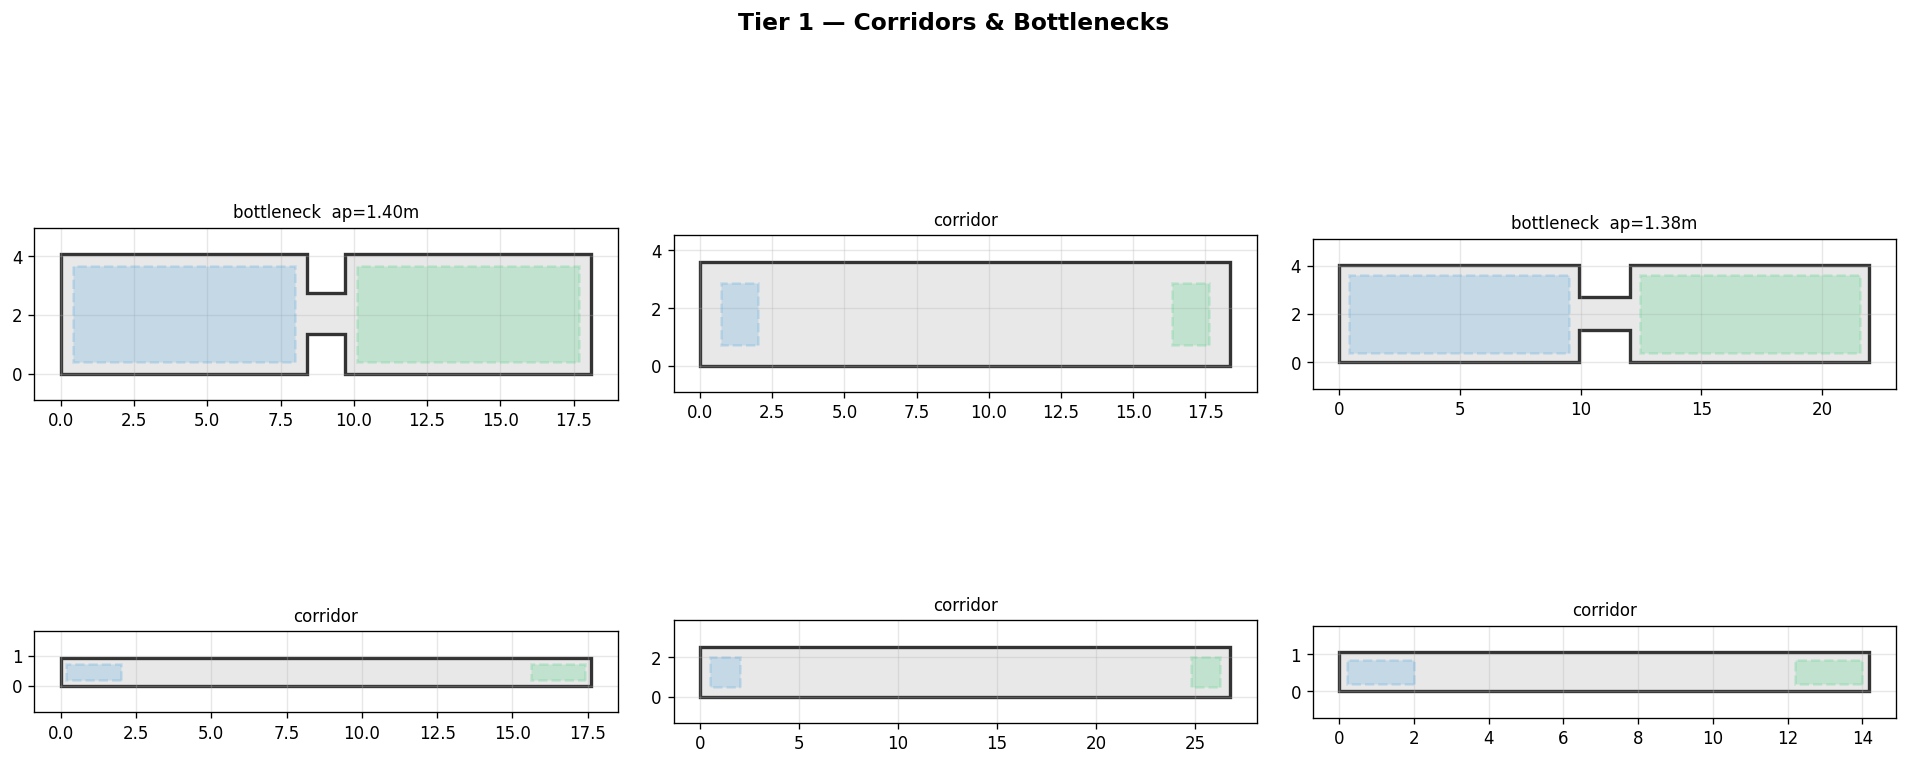

In [3]:
config = GeometryConfig(tier=GeometryTier.TIER_1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax in axes.flat:
    geom = generate_geometry(rng, config)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    shape = geom.metadata.get("shape", "?")
    extra = f"  ap={geom.metadata['aperture']:.2f}m" if "aperture" in geom.metadata else ""
    ax.set_title(f"{shape}{extra}", fontsize=10)

fig.suptitle("Tier 1 — Corridors & Bottlenecks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Tier 2 — Branching Geometries

L-bends, T-junctions, and crossroads. These require agents to navigate around
corners and make route-choice decisions.

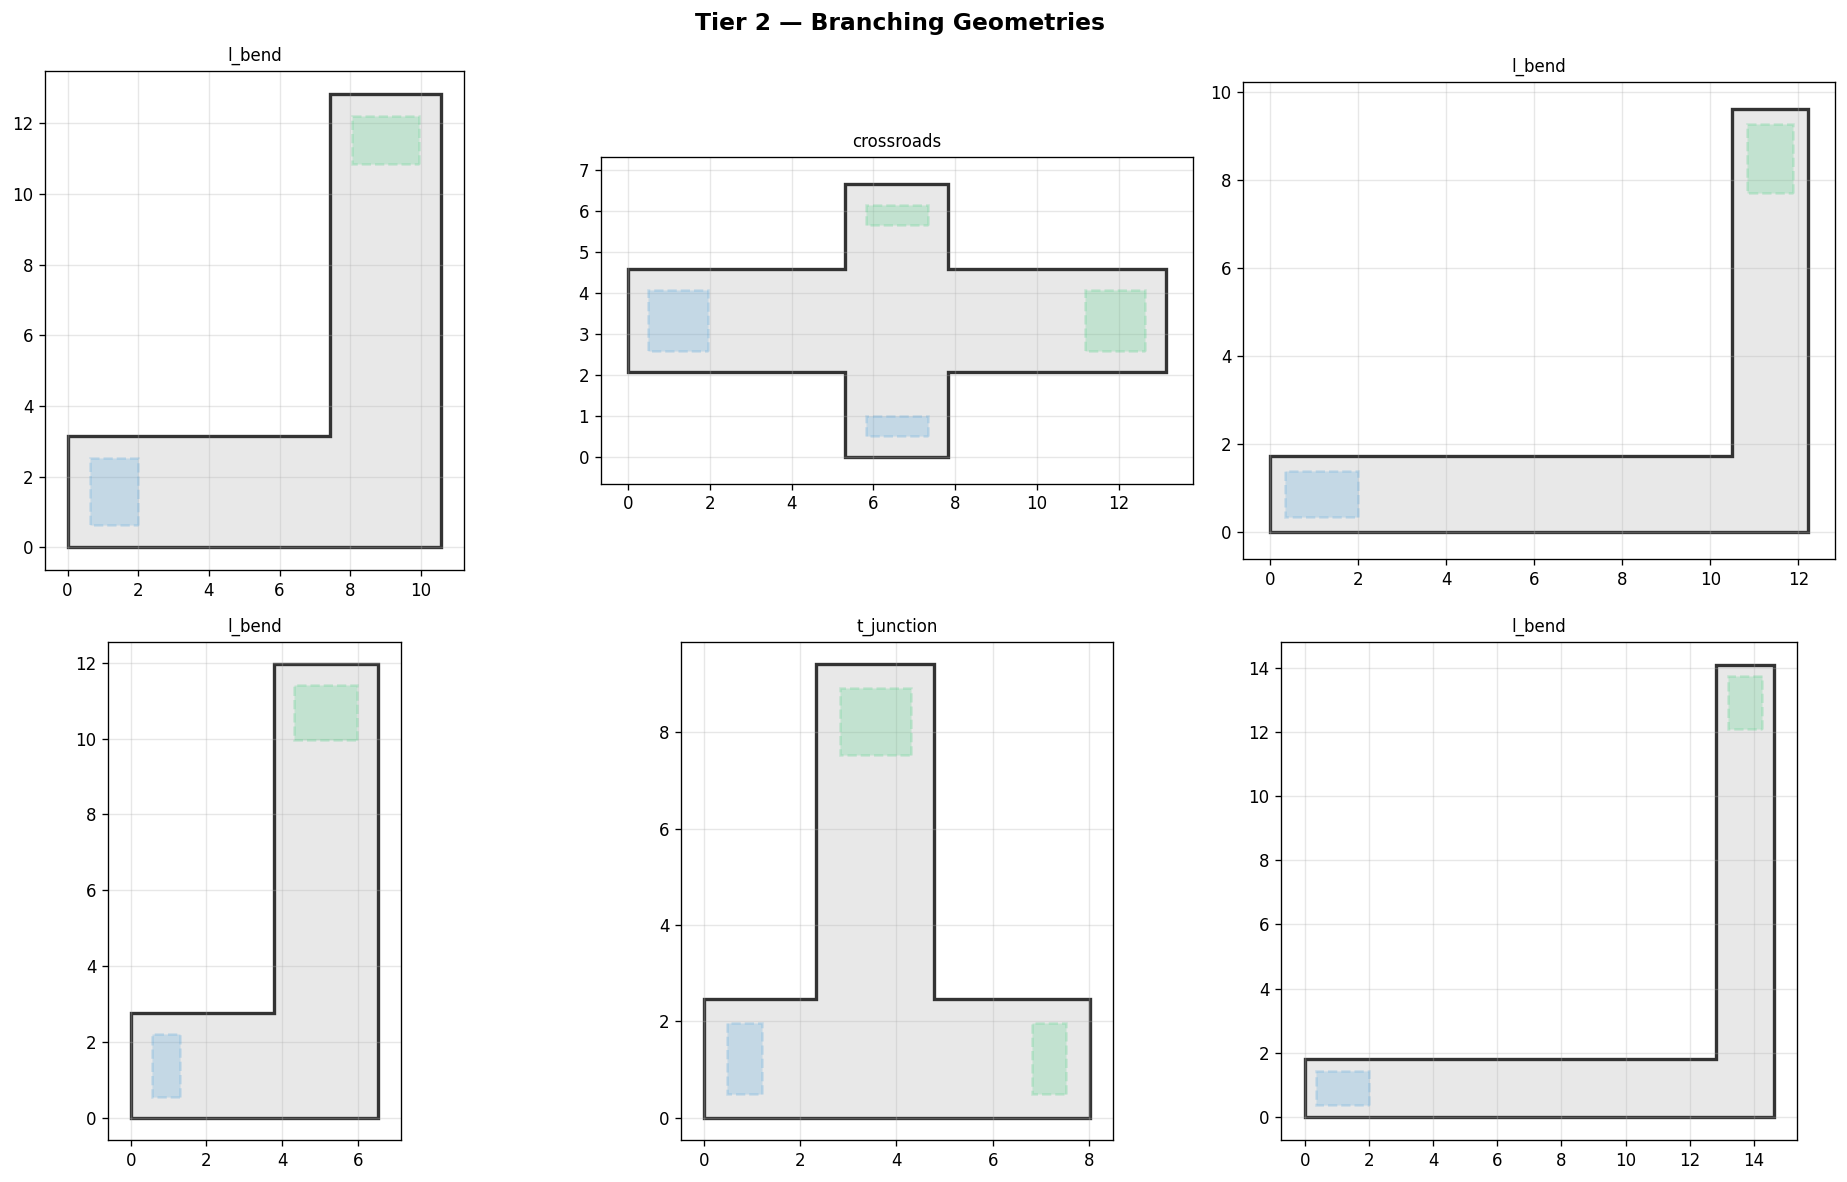

In [4]:
config = GeometryConfig(tier=GeometryTier.TIER_2)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax in axes.flat:
    geom = generate_geometry(rng, config)
    plot_geometry(geom.polygon, ax=ax)
    plot_spawn_goal_regions(geom, ax)
    ax.set_title(f"{geom.metadata.get('shape', '?')}", fontsize=10)

fig.suptitle("Tier 2 — Branching Geometries", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Navigation Mesh

The navmesh is a constrained Delaunay triangulation of the walkable polygon.
It provides:
1. **A* pathfinding** on the triangle adjacency graph — finds the corridor of triangles
2. **Funnel algorithm** (Simple Stupid Funnel) — computes the geometrically shortest
   (taut-string) path through the portal edges of that corridor
3. **Waypoint direction** — 2D observation signal pointing toward the next turning point
4. **Path deviation** — scalar measuring how much longer the walkable path is vs. the straight line

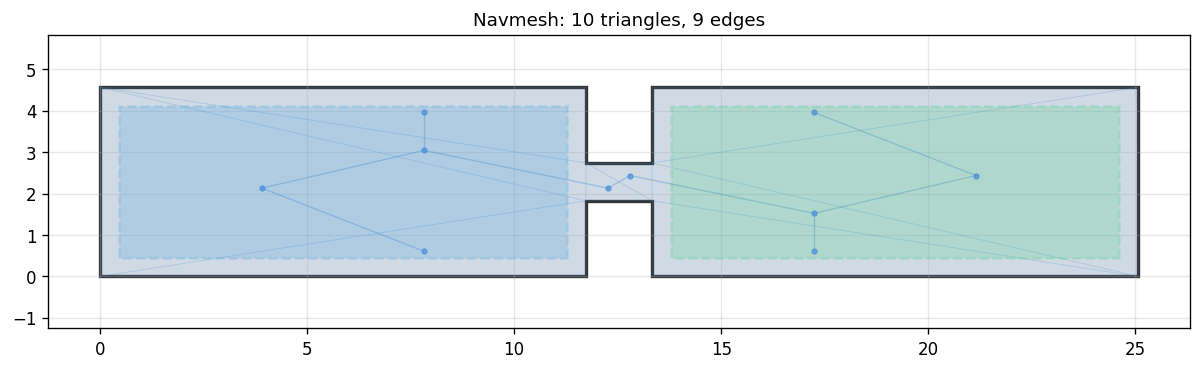

In [5]:
# Build a bottleneck and show the navmesh
config = GeometryConfig(tier=GeometryTier.TIER_1)
geom = generate_geometry(np.random.default_rng(7), config)

navmesh = build_navmesh(geom.polygon)

fig, ax = visualise_generated_geometry(geom, show_navmesh=True, navmesh=navmesh)
ax.set_title(
    f"Navmesh: {len(navmesh.triangles)} triangles, "
    f"{sum(len(a) for a in navmesh.adjacency) // 2} edges",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Shortest Path: A* + Funnel Algorithm

A* finds the triangle corridor; the funnel algorithm then computes the
true shortest (taut-string) path through the portal edges between those triangles.

The funnel-smoothed path is geometrically optimal — it hugs corners exactly like
a taut string pulled through the corridor. This is the same path quality that
JuPedSim's built-in routing produces.

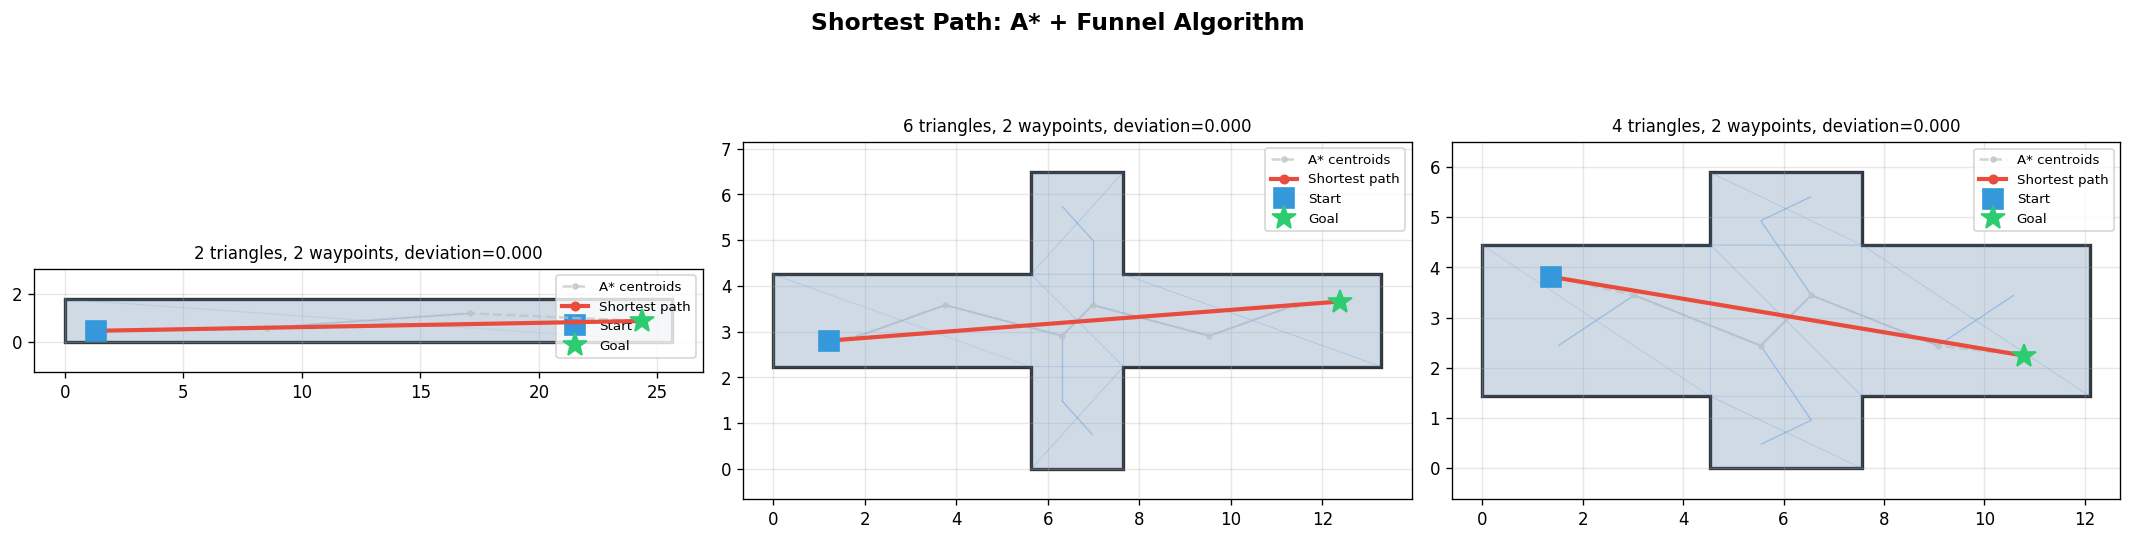

In [6]:
def plot_shortest_path(navmesh, start, goal, ax):
    """Visualise the funnel-smoothed shortest path and the A* triangle corridor."""
    tri_path = find_path(navmesh, start, goal)
    if tri_path is None:
        ax.set_title("No path found!", color="red")
        return

    # Draw A* centroid path (faint, for comparison)
    centroids_path = np.array([start] + [navmesh.centroids[i] for i in tri_path] + [goal])
    ax.plot(centroids_path[:, 0], centroids_path[:, 1], "o--", color="#bdc3c7",
            linewidth=1.5, markersize=3, zorder=10, alpha=0.7, label="A* centroids")

    # Draw funnel-smoothed shortest path
    waypoints = shortest_path(navmesh, start, goal)
    if waypoints is not None and len(waypoints) >= 2:
        wp = np.array(waypoints)
        ax.plot(wp[:, 0], wp[:, 1], "o-", color="#e74c3c",
                linewidth=2.5, markersize=5, zorder=15, label="Shortest path")

    # Mark start and goal
    ax.plot(*start, "s", color="#3498db", markersize=12, zorder=20, label="Start")
    ax.plot(*goal, "*", color="#2ecc71", markersize=15, zorder=20, label="Goal")

    dev = path_deviation(navmesh, start, goal)
    n_waypoints = len(waypoints) if waypoints else 0
    ax.set_title(f"{len(tri_path)} triangles, {n_waypoints} waypoints, deviation={dev:.3f}", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")


# Show paths in three different geometries
seeds = [3, 10, 21]
tiers = [GeometryTier.TIER_1, GeometryTier.TIER_2, GeometryTier.TIER_2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, seed, tier in zip(axes, seeds, tiers):
    r = np.random.default_rng(seed)
    geom = generate_geometry(r, GeometryConfig(tier=tier))
    nm = build_navmesh(geom.polygon)

    start = sample_point_in_polygon(geom.spawn_regions[0], r)
    goal = sample_point_in_polygon(geom.goal_regions[0], r)

    plot_geometry(geom.polygon, ax=ax)
    plot_navmesh(nm, ax, show_adjacency=True)
    plot_shortest_path(nm, start, goal, ax)

fig.suptitle("Shortest Path: A* + Funnel Algorithm", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Solvability Check

The navmesh lets us quickly verify whether all (spawn, goal) pairs are reachable.
This is used during environment generation to prune or regenerate unsolvable configurations.

In [7]:
rng = np.random.default_rng(99)
config = GeometryConfig(tier=GeometryTier.TIER_2)

n_tests = 50
n_pairs = 20

results = []
for _ in range(n_tests):
    geom = generate_geometry(rng, config)
    nm = build_navmesh(geom.polygon)
    reachable = 0
    for _ in range(n_pairs):
        s = sample_point_in_polygon(geom.spawn_regions[0], rng)
        g = sample_point_in_polygon(geom.goal_regions[0], rng)
        if is_reachable(nm, s, g):
            reachable += 1
    results.append(reachable / n_pairs)

print(f"Solvability across {n_tests} Tier 2 geometries ({n_pairs} pairs each):")
print(f"  Mean: {np.mean(results):.1%}")
print(f"  Min:  {np.min(results):.1%}")
print(f"  Max:  {np.max(results):.1%}")

Solvability across 50 Tier 2 geometries (20 pairs each):
  Mean: 100.0%
  Min:  100.0%
  Max:  100.0%


## Custom Geometry Import

Any Shapely Polygon works — including imported IAS-7 test geometries.
Here we manually define a bottleneck matching a real experiment setup.

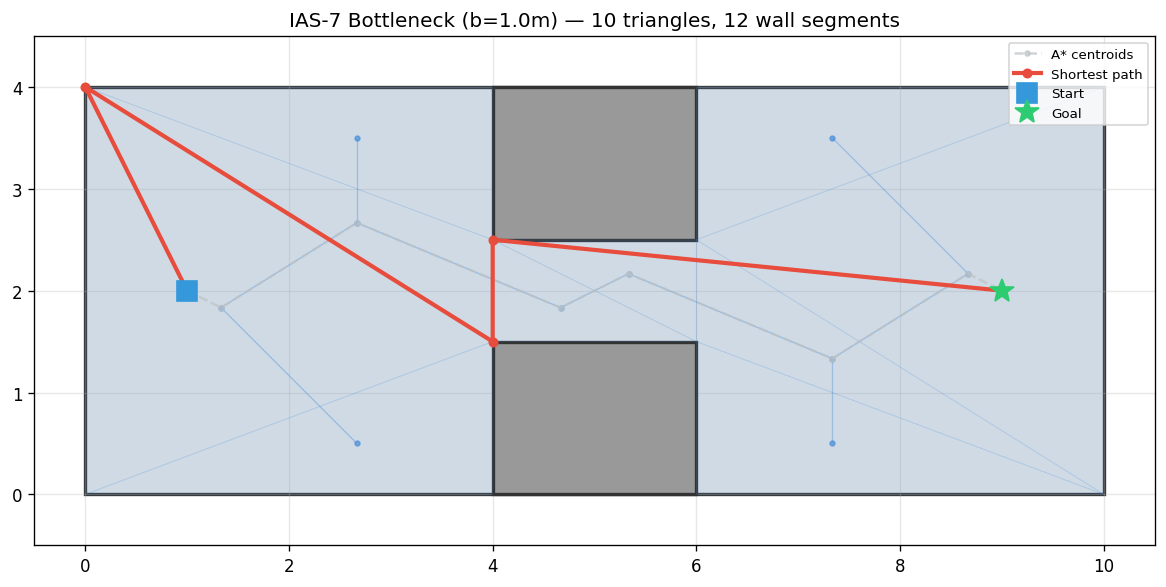

In [8]:
# IAS-7-style bottleneck: 10m corridor, 1.0m aperture
exterior = [(0, 0), (10, 0), (10, 4), (0, 4)]
top_wall = [(4, 2.5), (6, 2.5), (6, 4), (4, 4)]
bottom_wall = [(4, 0), (6, 0), (6, 1.5), (4, 1.5)]
ias7_bottleneck = Polygon(exterior, [top_wall, bottom_wall])

nm = build_navmesh(ias7_bottleneck)
walls = extract_wall_segments(ias7_bottleneck)

fig, ax = plt.subplots(figsize=(12, 5))
plot_geometry(ias7_bottleneck, ax=ax)
plot_navmesh(nm, ax, show_centroids=True, show_adjacency=True)

# Show funnel-smoothed shortest path through the bottleneck
start = np.array([1.0, 2.0])
goal = np.array([9.0, 2.0])
plot_shortest_path(nm, start, goal, ax)

ax.set_title(f"IAS-7 Bottleneck (b=1.0m) — {len(nm.triangles)} triangles, {walls.shape[0]} wall segments")
plt.tight_layout()
plt.show()